Cargado experiment_results_h1024.csv: 1 experimentos
Cargado experiment_results_h128.csv: 6 experimentos
Cargado experiment_results_h256.csv: 3 experimentos
Cargado experiment_results_h512.csv: 26 experimentos
Cargado experiment_results_h64.csv: 6 experimentos

Total: 42 experimentos combinados

RESULTADOS DE EXPERIMENTOS


,timestamp,hidden_size,num_epochs,epochs_trained,batch_size,learning_rate,patience,clip_value,dropout_rate,optimizer,activation,weight_init,best_val_loss,test_accuracy,avg_epoch_time_seconds,device,vocab_size,seq_length,training_time_seconds
0,2026-01-08T00:57:24.546641,1024,100,12,1024,0.002,5,1.0,0.5,RMSProp,relu,xavier,1.394486,0.580249,2.867,cuda,29,20,NaN
1,2026-01-08T00:01:41.291288,128,10,10,32,0.010,10,1.0,0.5,RMSProp,relu,xavier,2.113203,0.400622,NaN,cpu,29,20,28.92
2,2026-01-08T00:07:40.193636,128,10,10,32,0.010,10,1.0,0.5,AdamW,relu,xavier,2.114800,0.388737,NaN,cpu,29,20,29.90
3,2026-01-08T00:09:32.857951,128,10,10,32,0.001,10,1.0,0.5,RMSProp,relu,xavier,2.872182,0.291636,NaN,cpu,29,20,28.44
4,2026-01-08T00:11:24.328322,128,10,10,32,0.001,10,1.0,0.5,AdamW,relu,xavier,2.930189,0.213136,NaN,cpu,29,20,29.21
5,2026-01-08T00:13:10.990218,128,10,10,32,0.100,10,1.0,0.5,AdamW,relu,xavier,2.245194,0.377808,NaN,cpu,29,20,28.98
6,2026-01-08T00:23:33.523865,128,10,10,32,0.100,10,1.0,0.5,RMSProp,relu,xavier,2.234086,0.378189,NaN,cpu,29,20,29.05
7,2026-01-08T00:26:06.128923,256,10,10,32,0.010,10,1.0,0.5,RMSProp,relu,xavier,1.983542,0.429786,NaN,cpu,29,20,81.51
8,2026-01-08T00:28:40.067004,256,10,10,32,0.010,10,1.0,0.5,AdamW,relu,xavier,1.985226,0.426646,NaN,cpu,29,20,84.68
9,2026-01-08T00:42:10.332609,256,100,24,128,0.004,5,1.0,0.5,AdamW,relu,xavier,1.438538,0.559300,NaN,cuda,29,20,47.92



🏆 MEJOR RESULTADO GLOBAL:
   Accuracy: 58.04%
   Hidden size: 512
   Batch size: 1024
   Optimizer: RMSProp
   Learning rate: 0.002
   Dropout: 0.5
   Activation: relu
   Weight init: xavier

🏆 MEJOR RESULTADO POR HIDDEN SIZE:

  Hidden Size 64:
    Accuracy: 38.17%
    Optimizer: AdamW, LR: 0.1, Dropout: 0.5

  Hidden Size 128:
    Accuracy: 40.06%
    Optimizer: RMSProp, LR: 0.01, Dropout: 0.5

  Hidden Size 256:
    Accuracy: 55.93%
    Optimizer: AdamW, LR: 0.004, Dropout: 0.5

  Hidden Size 512:
    Accuracy: 58.04%
    Optimizer: RMSProp, LR: 0.002, Dropout: 0.5

  Hidden Size 1024:
    Accuracy: 58.02%
    Optimizer: RMSProp, LR: 0.002, Dropout: 0.5


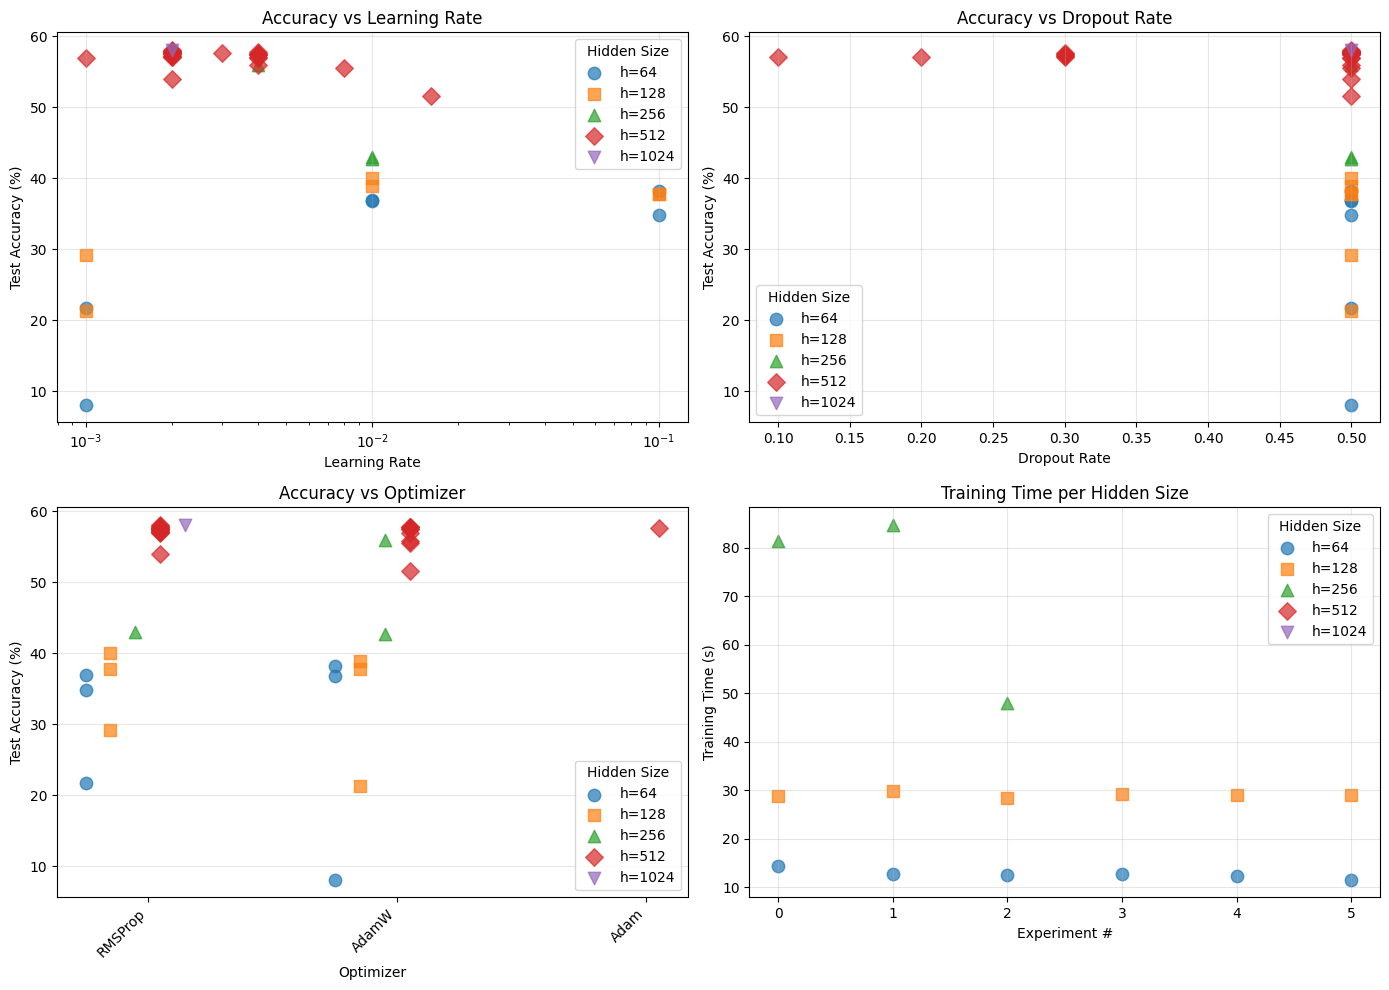


ESTADÍSTICAS POR HIDDEN SIZE
             Experiments  Avg Accuracy  Best Accuracy
hidden_size                                          
64                     6      0.294154       0.381695
128                    6      0.341688       0.400622
256                    3      0.471911       0.559300
512                   26      0.569909       0.580428
1024                   1      0.580249       0.580249


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# =============================================
# Cargar todos los CSV de resultados
# =============================================
csv_files = glob.glob("experiment_results_h*.csv")

if not csv_files:
    print("❌ No se encontraron archivos experiment_results_h*.csv")
else:
    dfs = []
    for f in sorted(csv_files):
        df_temp = pd.read_csv(f)
        print(f"Cargado {f}: {len(df_temp)} experimentos")
        dfs.append(df_temp)
    
    df = pd.concat(dfs, ignore_index=True)
    print(f"\nTotal: {len(df)} experimentos combinados")

    # Mostrar tabla completa
    print("\n" + "=" * 100)
    print("RESULTADOS DE EXPERIMENTOS")
    print("=" * 100)
    display(df)

    # Mejor resultado GLOBAL
    best_idx = df['test_accuracy'].astype(float).idxmax()
    best = df.loc[best_idx]
    print(f"\n🏆 MEJOR RESULTADO GLOBAL:")
    print(f"   Accuracy: {float(best['test_accuracy'])*100:.2f}%")
    print(f"   Hidden size: {best['hidden_size']}")
    print(f"   Batch size: {best['batch_size']}")
    print(f"   Optimizer: {best['optimizer']}")
    print(f"   Learning rate: {best['learning_rate']}")
    print(f"   Dropout: {best['dropout_rate']}")
    print(f"   Activation: {best['activation']}")
    print(f"   Weight init: {best['weight_init']}")

    # Mejor resultado POR CADA HIDDEN_SIZE
    print(f"\n{'='*60}")
    print("🏆 MEJOR RESULTADO POR HIDDEN SIZE:")
    print(f"{'='*60}")
    hidden_sizes = sorted(df['hidden_size'].unique())
    for hs in hidden_sizes:
        subset = df[df['hidden_size'] == hs]
        best_idx_hs = subset['test_accuracy'].astype(float).idxmax()
        best_hs = subset.loc[best_idx_hs]
        print(f"\n  Hidden Size {hs}:")
        print(f"    Accuracy: {float(best_hs['test_accuracy'])*100:.2f}%")
        print(f"    Optimizer: {best_hs['optimizer']}, LR: {best_hs['learning_rate']}, Dropout: {best_hs['dropout_rate']}")

    # Marcadores y colores para cada hidden_size
    markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '*', 'X', 'P']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    hs_to_marker = {hs: markers[i % len(markers)] for i, hs in enumerate(hidden_sizes)}
    hs_to_color = {hs: colors[i % len(colors)] for i, hs in enumerate(hidden_sizes)}

    # Gráficas
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Accuracy por Learning Rate
    ax1 = axes[0, 0]
    for hs in hidden_sizes:
        subset = df[df['hidden_size'] == hs]
        ax1.scatter(subset['learning_rate'], subset['test_accuracy'].astype(float)*100, 
                   marker=hs_to_marker[hs], c=hs_to_color[hs], label=f'h={hs}', s=80, alpha=0.7)
    ax1.set_xlabel('Learning Rate')
    ax1.set_ylabel('Test Accuracy (%)')
    ax1.set_title('Accuracy vs Learning Rate')
    ax1.set_xscale('log')
    ax1.legend(title='Hidden Size')
    ax1.grid(True, alpha=0.3)

    # 2. Accuracy por Dropout Rate
    ax2 = axes[0, 1]
    for hs in hidden_sizes:
        subset = df[df['hidden_size'] == hs]
        ax2.scatter(subset['dropout_rate'], subset['test_accuracy'].astype(float)*100, 
                   marker=hs_to_marker[hs], c=hs_to_color[hs], label=f'h={hs}', s=80, alpha=0.7)
    ax2.set_xlabel('Dropout Rate')
    ax2.set_ylabel('Test Accuracy (%)')
    ax2.set_title('Accuracy vs Dropout Rate')
    ax2.legend(title='Hidden Size')
    ax2.grid(True, alpha=0.3)

    # 3. Accuracy por Optimizer
    ax3 = axes[1, 0]
    optimizers = df['optimizer'].unique()
    opt_to_x = {opt: i for i, opt in enumerate(optimizers)}
    for hs in hidden_sizes:
        subset = df[df['hidden_size'] == hs]
        x_vals = [opt_to_x[opt] + (list(hidden_sizes).index(hs) - len(hidden_sizes)/2) * 0.1 for opt in subset['optimizer']]
        ax3.scatter(x_vals, subset['test_accuracy'].astype(float)*100, 
                   marker=hs_to_marker[hs], c=hs_to_color[hs], label=f'h={hs}', s=80, alpha=0.7)
    ax3.set_xticks(range(len(optimizers)))
    ax3.set_xticklabels(optimizers, rotation=45, ha='right')
    ax3.set_xlabel('Optimizer')
    ax3.set_ylabel('Test Accuracy (%)')
    ax3.set_title('Accuracy vs Optimizer')
    ax3.legend(title='Hidden Size')
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Tiempo de entrenamiento
    ax4 = axes[1, 1]
    for hs in hidden_sizes:
        subset = df[df['hidden_size'] == hs]
        ax4.scatter(range(len(subset)), subset['training_time_seconds'].astype(float), 
                   marker=hs_to_marker[hs], c=hs_to_color[hs], label=f'h={hs}', s=80, alpha=0.7)
    ax4.set_xlabel('Experiment #')
    ax4.set_ylabel('Training Time (s)')
    ax4.set_title('Training Time per Hidden Size')
    ax4.legend(title='Hidden Size')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Estadísticas
    print("\n" + "=" * 60)
    print("ESTADÍSTICAS POR HIDDEN SIZE")
    print("=" * 60)
    stats = df.groupby('hidden_size')['test_accuracy'].agg(['count', 'mean', 'max']).rename(
        columns={'count': 'Experiments', 'mean': 'Avg Accuracy', 'max': 'Best Accuracy'}
    )
    print(stats.to_string())